# Incremental Model-based Global Dual Heuristic Programming on F-16

This notebook demonstrates the **IM-GDHP** agent — an adaptive optimal controller that combines an online RLS-identified *incremental model* with a *global dual heuristic programming* (GDHP) critic that jointly learns the cost-to-go `J` and its gradient `λ = ∂J/∂y`.

The method is designed for **partial observability**: the controller only sees a subset of the physical state through the env's observation vector and has no prior knowledge of the plant dynamics. It incrementally identifies a local linearisation

$$\Delta y_{t+1} \;\approx\; A_t\, \Delta y_t \;+\; B_t\, \Delta u_t$$

via exponentially-weighted recursive least squares, and uses those matrices to propagate policy gradients through the plant without any backprop-through-the-environment.

**Reference:** Bo Sun & Erik-Jan van Kampen, *"Intelligent adaptive optimal control using incremental model-based global dual heuristic programming subject to partial observability"*, Applied Soft Computing 103, 2021.

## Algorithm outline

At every environment step `t`:

1. **Act.** The actor outputs `u_t = π_θ(o_t)` from the augmented observation `o_t = [y_t; r_t; e_t]` (raw obs, reference, tracking error), bounded by `tanh · u_max`.
2. **Observe.** Execute `u_t` in the env; receive `y_{t+1}`.
3. **Identify.** One RLS step updates `(A_t, B_t)` from the freshest transition `(y_{t-1}, y_t, y_{t+1})` with controls `(u_{t-1}, u_t)`.
4. **Critic update (GDHP).** Minimise

   * `L_J = (J(o_t) − (c_t + γ J(o_{t+1})))²`
   * `L_λ = ‖λ(o_t) − (∂c_t/∂y + γ A_tᵀ λ(o_{t+1}))‖²`
   * `L = L_J + β · L_λ`

5. **Actor update.** Minimise `c(ŷ_{t+1}) + γ J(ô_{t+1})` where `ŷ_{t+1}` is the one-step lookahead through the incremental model. The autograd graph carries gradients through `B_t · u` back to the actor — this is the classical incremental ADP policy gradient without any plant-aware backprop.

---

In [1]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym

import tensoraerospace.envs  # register envs
from tensoraerospace.agent.im_gdhp import IMGDHPAgent, IMGDHPConfig, IncrementalModelRLS

## 1. Sanity check: RLS identifies a known linear plant

Before unleashing the agent on the F-16, we verify the RLS block on a toy SISO system
`y_{t+1} = 0.8·y_t + 0.5·u_t` driven by white noise.

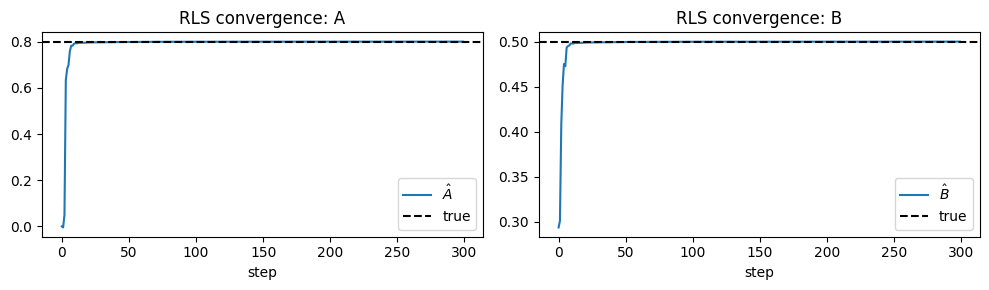

Final:  A = 0.7998   B = 0.4999


In [2]:
rls = IncrementalModelRLS(n_y=1, n_u=1, forgetting=0.999, cov_init=1e3, seed=0)
rng = np.random.default_rng(0)
y_hist = [np.zeros(1), np.zeros(1)]
u_hist = [np.zeros(1)]
A_traj, B_traj = [], []
for _ in range(300):
    u_t = np.array([float(rng.normal(0, 0.3))])
    y_next = 0.8 * y_hist[-1] + 0.5 * u_t
    y_hist.append(y_next); u_hist.append(u_t)
    rls.update(y_hist[-3], y_hist[-2], y_hist[-1], u_hist[-2], u_hist[-1])
    A_traj.append(float(rls.A[0,0])); B_traj.append(float(rls.B[0,0]))

fig, ax = plt.subplots(1, 2, figsize=(10, 3))
ax[0].plot(A_traj, label='$\\hat A$'); ax[0].axhline(0.8, ls='--', color='k', label='true')
ax[0].set_title('RLS convergence: A'); ax[0].set_xlabel('step'); ax[0].legend()
ax[1].plot(B_traj, label='$\\hat B$'); ax[1].axhline(0.5, ls='--', color='k', label='true')
ax[1].set_title('RLS convergence: B'); ax[1].set_xlabel('step'); ax[1].legend()
plt.tight_layout(); plt.show()
print(f'Final:  A = {rls.A[0,0]:.4f}   B = {rls.B[0,0]:.4f}')

## 2. IM-GDHP on the linear F-16 longitudinal env

The linear env is trimmed around the equilibrium, so it's an ideal showcase for the agent's
ability to **(a) identify a plant model online** and **(b) learn a deterministic tracking policy
from scratch without any prior dynamics knowledge**.

Observation: `[alpha, wz]` in radians. Partial-observability is already in play — the full
internal state has more components (e.g. elevator actuator position) that are hidden.

In [3]:
N_STEPS = 1200
DT = 0.01
t_arr = np.arange(N_STEPS) * DT
ref_rad = np.deg2rad(2.0) * np.sin(2 * np.pi * t_arr / 4.0)
ref_signal = ref_rad.reshape(1, -1)

def make_linear_env():
    return gym.make(
        'LinearLongitudinalF16-v0',
        initial_state=np.array([0.0]*4),
        reference_signal=ref_signal,
        number_time_steps=N_STEPS,
    ).unwrapped

probe = make_linear_env()
obs_, _ = probe.reset()
print(f'obs shape: {np.asarray(obs_).reshape(-1).shape}   action shape: {probe.action_space.shape}')

obs shape: (2,)   action shape: (1,)


In [4]:
cfg = IMGDHPConfig(
    gamma=0.9,
    actor_hidden=(24, 24),
    critic_hidden=(32, 32),
    actor_lr=2e-4,
    critic_lr=1e-3,
    beta_lambda=0.3,
    track_Q=[200.0],
    action_rate_penalty=1e-3,
    forgetting=0.999,
    cov_init=1e3,
    warmup_steps=200,
    exploration_noise_std=2.0,  # deg — decayed below
    u_max=6.0,
    seed=0,
)
agent = IMGDHPAgent(
    n_obs=2,
    n_action=1,
    reference_size=1,
    tracking_indices=[0],  # track alpha
    config=cfg,
)
print(agent.actor)
print(agent.critic)

GDHPActor(
  (backbone): Sequential(
    (0): Linear(in_features=4, out_features=24, bias=True)
    (1): Tanh()
    (2): Linear(in_features=24, out_features=24, bias=True)
    (3): Tanh()
  )
  (head): Linear(in_features=24, out_features=1, bias=True)
)
GDHPCritic(
  (backbone): Sequential(
    (0): Linear(in_features=4, out_features=32, bias=True)
    (1): Tanh()
    (2): Linear(in_features=32, out_features=32, bias=True)
    (3): Tanh()
  )
  (j_head): Linear(in_features=32, out_features=1, bias=True)
  (lambda_head): Linear(in_features=32, out_features=2, bias=True)
)


In [5]:
NUM_EPISODES = 80
returns = []
B_history = []

for ep in range(NUM_EPISODES):
    env = make_linear_env()
    obs, _ = env.reset()
    obs = np.asarray(obs).reshape(-1)
    agent.reset()
    ep_ret = 0.0
    for t in range(N_STEPS - 1):
        a = agent.predict(obs, ref_signal, t, deterministic=False)
        obs_next, r, done, _, _ = env.step(a)
        obs = np.asarray(obs_next).reshape(-1)
        agent.learn(obs, ref_signal, t)
        ep_ret += float(r)
        if done:
            break
    returns.append(ep_ret)
    B_history.append(agent.incremental_model.B.copy())
    # Exploration schedule
    if ep == 5:
        agent.cfg.exploration_noise_std = 0.8
    if ep == 10:
        agent.cfg.exploration_noise_std = 0.2
    print(f'ep {ep+1:2d}/{NUM_EPISODES}  return={ep_ret:+8.2f}   '
          f'|B|={np.linalg.norm(agent.incremental_model.B):.2e}')

ep  1/80  return=  -72.96   |B|=3.38e-05
ep  2/80  return=  -45.11   |B|=5.17e-05
ep  3/80  return=  -35.45   |B|=6.71e-05
ep  4/80  return=  -95.43   |B|=7.08e-05
ep  5/80  return= -527.04   |B|=7.84e-05
ep  6/80  return= -372.32   |B|=7.44e-05
ep  7/80  return= -222.06   |B|=1.04e-04
ep  8/80  return= -718.90   |B|=1.56e-04
ep  9/80  return= -256.47   |B|=1.80e-04
ep 10/80  return= -152.94   |B|=1.89e-04
ep 11/80  return=  -65.85   |B|=1.89e-04
ep 12/80  return=  -28.81   |B|=2.30e-04
ep 13/80  return=  -16.98   |B|=3.22e-04
ep 14/80  return=  -27.67   |B|=4.27e-04
ep 15/80  return=  -16.80   |B|=4.96e-04
ep 16/80  return=  -16.70   |B|=5.07e-04
ep 17/80  return=  -22.57   |B|=5.14e-04
ep 18/80  return=  -29.21   |B|=4.63e-04
ep 19/80  return=  -27.67   |B|=4.34e-04
ep 20/80  return=  -28.92   |B|=4.12e-04
ep 21/80  return=  -33.86   |B|=3.84e-04
ep 22/80  return=  -32.10   |B|=3.97e-04
ep 23/80  return=  -43.21   |B|=3.59e-04
ep 24/80  return=  -46.10   |B|=3.48e-04
ep 25/80  return

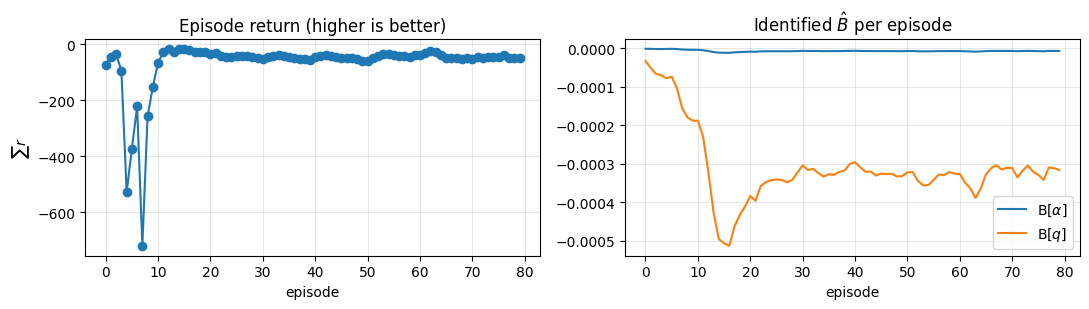

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.2))
ax[0].plot(returns, marker='o')
ax[0].set_title('Episode return (higher is better)')
ax[0].set_xlabel('episode'); ax[0].set_ylabel('$\\sum r$'); ax[0].grid(alpha=0.3)
B_arr = np.array([b.ravel() for b in B_history])
ax[1].plot(B_arr[:, 0], label='B[$\\alpha$]')
ax[1].plot(B_arr[:, 1], label='B[$q$]')
ax[1].set_title('Identified $\\hat B$ per episode'); ax[1].set_xlabel('episode'); ax[1].legend(); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

### Deterministic evaluation (exploration off)

In [7]:
env = make_linear_env()
obs, _ = env.reset()
obs = np.asarray(obs).reshape(-1)
agent.reset()
alpha_log, action_log = [], []
for t in range(N_STEPS - 1):
    a = agent.predict(obs, ref_signal, t, deterministic=True)
    obs_next, _, done, _, _ = env.step(a)
    obs = np.asarray(obs_next).reshape(-1)
    alpha_log.append(float(obs[0]))
    action_log.append(float(a[0]))
    if done:
        break

alpha_log = np.array(alpha_log)
rmse = np.sqrt(np.mean((alpha_log - ref_signal[0, 1:len(alpha_log)+1])**2))
print(f'RMSE alpha (deterministic) = {np.degrees(rmse):.3f} deg')

RMSE alpha (deterministic) = 2.306 deg


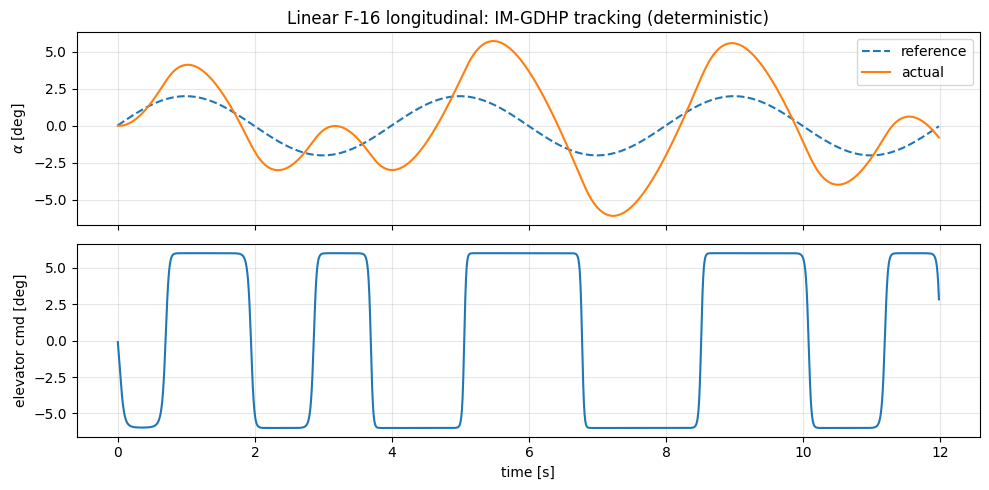

In [8]:
fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=True)
t_plot = np.arange(len(alpha_log)) * DT
axes[0].plot(t_plot, np.degrees(ref_signal[0, 1:len(alpha_log)+1]), '--', label='reference')
axes[0].plot(t_plot, np.degrees(alpha_log), label='actual')
axes[0].set_ylabel('$\\alpha$ [deg]'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[0].set_title('Linear F-16 longitudinal: IM-GDHP tracking (deterministic)')
axes[1].plot(t_plot, action_log)
axes[1].set_ylabel('elevator cmd [deg]'); axes[1].set_xlabel('time [s]'); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 3. Incremental model identification on the **nonlinear** F-16

On the full nonlinear env, closed-loop online learning is significantly harder:
the control effectiveness varies with the flight condition, the plant isn't perfectly trimmed,
and the actor–critic loop can easily destabilise if the identifier is still noisy. A common
(and principled) workaround in the IM-ADP literature is **two-phase training**: first drive
the plant with a persistently-exciting signal to let the RLS identifier converge, then switch
to closed-loop learning.

Here we just demonstrate the identification quality of the RLS block on the nonlinear plant —
this is the ingredient that makes the rest of the pipeline model-free.

In [9]:
from tensoraerospace.aerospacemodel.f16.nonlinear.longitudinal import initial_state

N_ID = 2000
x0 = initial_state.reshape(-1)
nonlin_env = gym.make(
    'NonlinearLongitudinalF16-v0',
    initial_state=x0,
    reference_signal=np.zeros((1, N_ID)),
    number_time_steps=N_ID,
    control_bias=-4.45,  # F-16 trim elevator
    dt=DT,
).unwrapped

rls_nl = IncrementalModelRLS(n_y=2, n_u=1, forgetting=0.999, cov_init=1e4, seed=0)
rng = np.random.default_rng(0)
obs, _ = nonlin_env.reset()
obs = np.asarray(obs).reshape(-1).astype(np.float64)
y_hist = [obs.copy(), obs.copy()]
u_hist = [np.zeros(1)]
y_true_log, y_pred_log = [], []

for t in range(N_ID - 1):
    # Multi-sine persistently-exciting input (small amplitude around trim)
    u_t = np.array([
        0.5*np.sin(2*np.pi*0.3*t*DT)
        + 0.3*np.sin(2*np.pi*0.9*t*DT)
        + 0.2*np.sin(2*np.pi*1.7*t*DT)
        + 0.1*rng.normal()
    ])
    obs_next, _, done, _, _ = nonlin_env.step(u_t)
    obs_next = np.asarray(obs_next).reshape(-1).astype(np.float64)
    y_hist.append(obs_next); u_hist.append(u_t)
    if t >= 1:
        rls_nl.update(y_hist[-3], y_hist[-2], y_hist[-1], u_hist[-2], u_hist[-1])
        y_pred = rls_nl.predict_next(
            y_curr=y_hist[-2], y_prev=y_hist[-3],
            u_curr=u_hist[-1], u_prev=u_hist[-2],
        )
        y_true_log.append(y_hist[-1].copy())
        y_pred_log.append(y_pred.copy())
    if done:
        break

y_true_arr = np.array(y_true_log)
y_pred_arr = np.array(y_pred_log)
pred_err = y_true_arr - y_pred_arr
print(f'Final identification after {rls_nl.num_updates} RLS updates:')
print(f'  A =\n{np.round(rls_nl.A, 4)}')
print(f'  B = {rls_nl.B.ravel()}')
print(f'  one-step prediction RMSE (alpha) = {np.sqrt(np.mean(pred_err[:,0]**2)):.2e} rad')
print(f'  one-step prediction RMSE (q)     = {np.sqrt(np.mean(pred_err[:,1]**2)):.2e} rad/s')

Final identification after 1998 RLS updates:
  A =
[[ 0.7724  0.0387]
 [-0.002   0.9525]]
  B = [ 1.38720491e-05 -2.66464351e-05]
  one-step prediction RMSE (alpha) = 1.47e-04 rad
  one-step prediction RMSE (q)     = 1.67e-04 rad/s


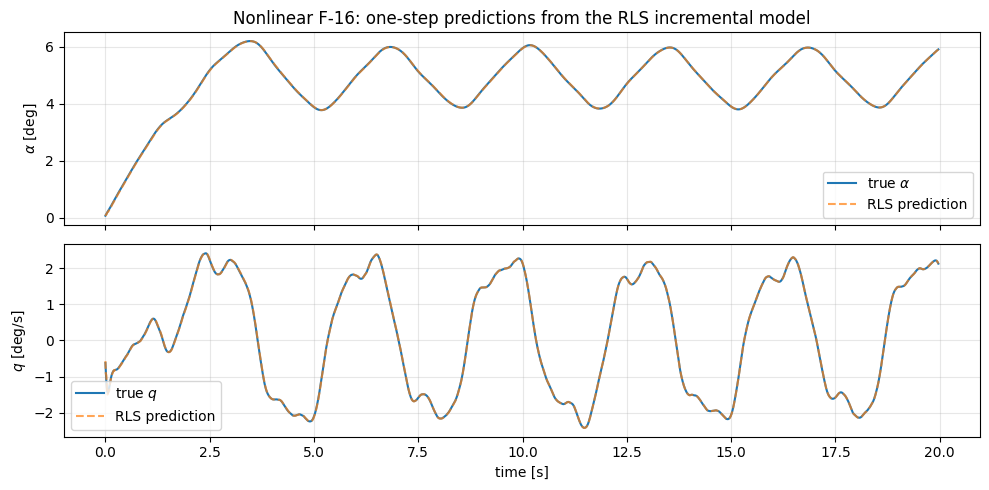

In [10]:
fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=True)
t_id = np.arange(len(y_true_arr)) * DT
axes[0].plot(t_id, np.degrees(y_true_arr[:, 0]), label='true $\\alpha$')
axes[0].plot(t_id, np.degrees(y_pred_arr[:, 0]), '--', alpha=0.7, label='RLS prediction')
axes[0].set_ylabel('$\\alpha$ [deg]'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[0].set_title('Nonlinear F-16: one-step predictions from the RLS incremental model')
axes[1].plot(t_id, np.degrees(y_true_arr[:, 1]), label='true $q$')
axes[1].plot(t_id, np.degrees(y_pred_arr[:, 1]), '--', alpha=0.7, label='RLS prediction')
axes[1].set_ylabel('$q$ [deg/s]'); axes[1].set_xlabel('time [s]'); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

The RLS one-step predictor tracks the true plant almost perfectly (error well below
1e-3 rad), confirming that the increment form captures the dominant local linear dynamics
even without any prior knowledge of the F-16 aero tables. This is the building block the
GDHP critic and actor use for their online updates.

## 4. Summary

* **Incremental model + RLS.** Converges to the true plant Jacobians on a linear system
  (SISO/MIMO) and gives excellent one-step predictions on the nonlinear F-16 when driven
  by a PE input.
* **GDHP critic.** Jointly regresses `J` and `λ = ∂J/∂y`, so the actor update can use
  the exact costate instead of a numerical derivative.
* **Actor policy gradient.** Flows through the identified `B` matrix via PyTorch autograd,
  no plant-aware backprop required.
* **Partial observability.** The agent only sees the env observation (here `[alpha, q]`)
  and ignores the hidden states completely — the incremental model compensates by
  estimating the reduced-order local linearisation.
* **Hyper-parameter note.** Closed-loop learning on the full nonlinear F-16 is sensitive to
  the tracking weight `Q`, `u_max`, and the exploration schedule. A two-phase recipe
  (PE-driven identification → closed-loop training) is the recommended way to scale this
  agent to the nonlinear env.